# EDA — Clima × Validaciones TransMilenio

**Entradas:** `dataset_limpio.csv` (producto del EDA de TransMilenio) y `clima_hora_*.csv` (Meteostat).
**Periodo:** 2026/07/01 - 2026/08/31 (62 días). **Unidad de análisis:** (estación, fecha, hora, línea).

Este notebook tiene dos objetivos:

1. **Construir `dataset_final_clima_transmilenio.csv`:** anexar las condiciones meteorológicas horarias al dataset limpio de validaciones y persistirlo.
2. **Explorar el efecto del clima:** comprobar si la lluvia (u otras condiciones) se asocia con un cambio en las validaciones.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def _buscar(rutas):
    for r in rutas:
        p = Path(r)
        if p.exists():
            return p
    return Path(rutas[0])

RUTA_LIMPIO = _buscar([
    "deliveries/week07/data_processed/dataset_limpio.csv",
    "../../data_processed/dataset_limpio.csv",
    "../data_processed/dataset_limpio.csv",
])
RUTA_CLIMA = _buscar([
    "deliveries/week07/data/clima/clima_hora_2026-07-01_a_2026-08-31.csv",
    "../../data/clima/clima_hora_2026-07-01_a_2026-08-31.csv",
    "../data/clima/clima_hora_2026-07-01_a_2026-08-31.csv",
])
RUTA_FINAL = RUTA_LIMPIO.parent / "dataset_final_clima_transmilenio.csv"

ORDEN_FRANJA = ["madrugada", "pico am", "valle", "pico pm", "noche"]

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (11, 4.5)

print("Dataset limpio:", RUTA_LIMPIO.resolve())
print("Clima horario :", RUTA_CLIMA.resolve())
print("Salida final  :", RUTA_FINAL.resolve())

Dataset limpio: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week07/data_processed/dataset_limpio.csv
Clima horario : /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week07/data/clima/clima_hora_2026-07-01_a_2026-08-31.csv
Salida final  : /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week07/data_processed/dataset_final_clima_transmilenio.csv


## 1. Construcción

### 1.1 Cargar el dataset limpio de validaciones

Leemos `dataset_limpio.csv`. La clave temporal es `Fecha` (`AAAA-MM-DD`) más `Hora` (0–23, hora en punto); sobre esa clave se hará la unión con el clima.

In [2]:
df = pd.read_csv(RUTA_LIMPIO)
print("Filas:", len(df), "| Columnas:", df.shape[1])
df.head(2)

Filas: 176783 | Columnas: 28


,num_est,Fecha,Hora,Linea,Tipo_Dia,Estacion,Latitud,Longitud,Ubicacion,Troncal,...,Tipo_Dia_ok,Sin_Oferta,Cap_total,sin_capacidad,DiaSemana,Franja,Es_Habil,Pax_bus,Ocupacion_pk,log_val
0,2000,2026-07-01,4,(33) Zona B AutoNorte,Dia 1,(02000) Portal Norte - Unicervantes,4.75,-74.05,CL 173,Autopista Norte,...,Dia 1,False,210.00,False,Miércoles,madrugada,True,5.45,2.41,6.23
1,2000,2026-07-01,5,(33) Zona B AutoNorte,Dia 1,(02000) Portal Norte - Unicervantes,4.75,-74.05,CL 173,Autopista Norte,...,Dia 1,False,210.00,False,Miércoles,pico am,True,12.66,18.93,8.29


### 1.2 Cargar el clima horario

El clima está descargado en 3 granularidades (hora / día / semana). Usamos la **horaria**, `fecha` llega como timestamp con zona `-05:00` (Bogotá); extraemos la parte de fecha y la hora para que coincidan con `Fecha`/`Hora` de TransMilenio.

In [3]:
clima = pd.read_csv(RUTA_CLIMA)
clima["fecha"] = pd.to_datetime(clima["fecha"])
clima["Fecha"] = clima["fecha"].dt.date.astype(str)
clima["Hora"] = clima["fecha"].dt.hour
print("Registros horarios:", len(clima))
print("Horas únicas (Fecha, Hora):", clima[["Fecha", "Hora"]].drop_duplicates().shape[0])
clima.head(2)

Registros horarios: 1488
Horas únicas (Fecha, Hora): 1488


,fecha,temp,rhum,prcp,wspd,wpgt,wdir,pres,cldc,coco,Fecha,Hora
0,2026-07-01 00:00:00-05:00,12.00,88,0.00,6.00,NaN,60,"1,027.00",2,3,2026-07-01,0
1,2026-07-01 01:00:00-05:00,11.00,94,0.00,5.00,NaN,50,"1,027.00",4,3,2026-07-01,1


### 1.3 Unir por `(Fecha, Hora)`

Hacemos un `left join` del dataset de validaciones contra el clima. Como el clima es una sola serie para toda la ciudad, cada hora climática se replica en las celdas (estación × línea) que comparten esa fecha y hora: la unión **no pierde filas ni duplica** (relación 1 clima -> N celdas).

In [4]:
antes = len(df)
clima_cols = ["Fecha", "Hora", "temp", "rhum", "prcp", "wspd", "wdir",
              "pres", "cldc", "wpgt", "coco"]
df = df.merge(clima[clima_cols], on=["Fecha", "Hora"], how="left")
print("Filas antes del join:", antes)
print("Filas después del join:", len(df))
print("Filas sin clima (esperado 0):", int(df["temp"].isna().sum()))

Filas antes del join: 176783
Filas después del join: 176783
Filas sin clima (esperado 0): 0


**Verificación de la unión:** el total de filas de validaciones se conservan y **ninguna queda sin clima**. La unión es completa porque TransMilenio no opera todas las horas (madrugadas sin servicio no existen en el dataset) y el clima sí cubre las 24 horas del período.

In [5]:
# Precipitación: NaN = hora sin registro de lluvia (no llovió).
prcp = df["prcp"].fillna(0.0)

df["clima_lluvia"] = prcp > 0
df["clima_lluvia_cat"] = pd.cut(prcp, bins=[-1.0, 0.0, 2.5, 10.0, np.inf],
                                labels=["sin_lluvia", "ligera", "moderada", "fuerte"])
df["clima_temp_cat"] = (pd.cut(df["temp"], bins=[-np.inf, 12.0, 17.0, np.inf],
                               labels=["<12", "12-17", ">17"]).astype(str))

resumen = pd.DataFrame({"N": df["clima_lluvia"].value_counts(dropna=False).sort_index()})
resumen["pct"] = (100 * resumen["N"] / len(df)).round(2)
print(resumen)
print()
print("Categorías de lluvia y temperatura:")
print(df["clima_lluvia_cat"].value_counts(dropna=False))
print(df["clima_temp_cat"].value_counts(dropna=False).sort_index())

                   N   pct
clima_lluvia              
False         169526 95.89
True            7257  4.11

Categorías de lluvia y temperatura:
clima_lluvia_cat
sin_lluvia    169526
ligera          7257
moderada           0
fuerte             0
Name: count, dtype: int64
clima_temp_cat
12-17    89524
<12      38112
>17      49147
Name: count, dtype: int64


**Hallazgo de cobertura:** solo **4.1 %** de las celdas (7,257) cayeron en una hora con lluvia. Corresponden a **50 horas lluviosas** de las 1,488 del período y, además, toda la lluvia es **ligera** (< 2.5 mm/h): las categorías `moderada` y `fuerte` no tienen datos en este período, así que el análisis se hará con el binario `clima_lluvia`.

In [6]:
print("Guardado:", RUTA_FINAL.resolve())
print("Filas:", len(df), "| Columnas:", df.shape[1])
print("Columnas nuevas vs dataset_limpio:", [c for c in df.columns
                                             if c in ("temp", "prcp") or c.startswith("clima_")])

Guardado: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week07/data_processed/dataset_final_clima_transmilenio.csv
Filas: 176783 | Columnas: 40
Columnas nuevas vs dataset_limpio: ['temp', 'prcp', 'clima_lluvia', 'clima_lluvia_cat', 'clima_temp_cat']


**Dataset generado:** con las **26 columnas** del dataset limpio más **9 de clima crudas** (`temp, rhum, prcp, wspd, wdir, pres, cldc, wpgt, coco`) más **3 derivadas** (`clima_lluvia`, `clima_lluvia_cat`, `clima_temp_cat`).

## 2. Efecto del clima sobre las validaciones

**Pregunta:** ¿las validaciones cambian cuando llueve (u otra condición climática)?

La demanda depende de la hora, el tipo de día y la estación, así que no se compara la demanda cruda. Definimos un **esperado** por celda `(num_est × Hora × DiaSemana)`: la mediana de las horas *sin lluvia* de esa misma combinación. A partir de él medimos:

- `esp` = validaciones esperadas de la celda.
- `diff` = `Validaciones − esp` (desvío absoluto).
- `ratio` = `diff / esp` (desvío relativo; −0.10 = "10 % menos de lo esperado").

In [7]:
sin_lluvia = df.loc[~df["clima_lluvia"]]
base = (sin_lluvia
        .groupby(["num_est", "Hora", "DiaSemana"])["Validaciones"]
        .median().rename("esp"))
df = df.join(base, on=["num_est", "Hora", "DiaSemana"])
df["diff"] = df["Validaciones"] - df["esp"]
df["ratio"] = df["diff"] / df["esp"].replace(0, np.nan)

print("Celda de referencia = mediana de horas sin lluvia"
      " (misma estación, hora y día de la semana).")
df[["Validaciones", "esp", "diff", "ratio"]].describe()

Celda de referencia = mediana de horas sin lluvia (misma estación, hora y día de la semana).


,Validaciones,esp,diff,ratio
count,"176,783.00","176,778.00","176,778.00","176,778.00"
mean,502.79,528.05,-25.25,-0.00
std,941.18,968.99,269.11,1.60
min,1.00,1.00,"-11,807.00",-1.00
25%,75.00,82.00,-16.00,-0.09
50%,227.00,245.00,0.00,0.00
75%,518.00,546.00,14.00,0.07
max,"15,308.00","14,461.00","3,766.00",618.00


### 2.1 Índice de demanda horario (nivel sistema)

Agregamos todas las estaciones de cada hora:

`índice = Σ_validaciones de la hora / Σ_esp de la hora`

Un índice < 1 indica una hora con menos demanda que su esperado; = 1, comportamiento normal.

In [8]:
idx = (df.groupby(["Fecha", "Hora", "clima_lluvia", "Es_Festivo"])
        .apply(lambda g: g["Validaciones"].sum() / g["esp"].sum(),
               include_groups=False)
        .rename("idx").reset_index())

print("Índice de demanda por hora, según lluvia:")
print(idx.groupby("clima_lluvia")["idx"].describe()[["count", "mean", "50%", "std"]].round(3))

Índice de demanda por hora, según lluvia:
                count  mean  50%  std
clima_lluvia                         
False        1,306.00  0.99 1.01 0.23
True            50.00  0.76 0.95 0.31


La mediana de las horas con lluvia es **0.95** frente a **1.01** sin lluvia, pero la **media** con lluvia cae a 0.76: pocas horas extremas tiran del promedio. Conviene ver cuáles son esas horas.

In [9]:
lluvia = idx[idx["clima_lluvia"]].sort_values("idx")
print("Las 50 horas con lluvia, ordenadas por índice (menor = peor):")
print(lluvia.to_string(index=False))

Las 50 horas con lluvia, ordenadas por índice (menor = peor):
     Fecha  Hora  clima_lluvia  Es_Festivo  idx
2026-07-20    22          True        True 0.16
2026-07-20    17          True        True 0.20
2026-08-17    17          True        True 0.21
2026-07-20    16          True        True 0.25
2026-08-17    16          True        True 0.26
2026-07-20    18          True        True 0.27
2026-08-17    18          True        True 0.30
2026-07-20    19          True        True 0.39
2026-08-17    15          True        True 0.40
2026-07-20    15          True        True 0.40
2026-08-17    12          True        True 0.42
2026-08-17    11          True        True 0.43
2026-08-17    19          True        True 0.44
2026-08-17    13          True        True 0.44
2026-08-17    14          True        True 0.45
2026-07-20    14          True        True 0.46
2026-07-20    21          True        True 0.48
2026-07-20    20          True        True 0.50
2026-07-04    13          

**Hallazgo — el efecto aparente es un artefacto de días festivos:** de las 50 horas con lluvia, las **18 más anómalas** (índice < 0.8) caen en solo **2 lunes festivos**: **2026-07-20** (Independencia de Colombia) y **2026-08-17** (Asunción de la Virgen, movida a lunes). Esos días cierran con aprox. 500 mil validaciones en total (nivel de un domingo), no 1.8 M de un lunes normal; su caída no la genera la lluvia, sino el tipo de día. El dataset ya los identifica correctamente como festivos mediante `Es_Festivo` / `Tipo_Dia_ok`.

In [10]:
normales = idx.loc[~idx["Es_Festivo"]]
print("Horas totales (excluyendo festivos):", len(normales))
print("Horas con lluvia en jornada normal:", int(normales["clima_lluvia"].sum()))
print()
print("Comparación SOLO de horas con jornada normal (festivos excluidos):")
print(normales.groupby("clima_lluvia")["idx"].describe()
      [["count", "mean", "50%", "std"]].round(3))


Horas totales (excluyendo festivos): 1269
Horas con lluvia en jornada normal: 32

Comparación SOLO de horas con jornada normal (festivos excluidos):
                count  mean  50%  std
clima_lluvia                         
False        1,237.00  1.03 1.01 0.17
True            32.00  0.98 0.98 0.03


**Hallazgo:** excluyendo las horas festivas (`Es_Festivo == False`), la mediana del índice es **0.98 en las 32 horas con lluvia** frente a **1.01 en las 1,237 horas sin lluvia**. Traducido: la lluvia ligera de este período se asocia a una caída de **aprox. 3 %**, dentro de la variabilidad normal del sistema.

### 2.2 Viento, temperatura y otras condiciones

Además de la lluvia, verificamos si el **viento** (hasta 19 km/h) o la **temperatura** (de 4 a 21 °C) alteran el índice de demanda horario. Usamos el mismo criterio: solo horas sin festivos (`Es_Festivo == False`). En Bogotá no hay calor extremo en el período (máx. 21 °C).

In [11]:
m = idx.loc[~idx["Es_Festivo"]].merge(
    clima[["Fecha", "Hora", "temp", "wspd", "rhum", "cldc", "coco"]],
    on=["Fecha", "Hora"], how="left")

m["temp_cat"] = pd.cut(m["temp"], bins=[-np.inf, 10, 12, 14, 16, np.inf],
                       labels=["<10", "10-12", "12-14", "14-16", ">16"])
m["wspd_cat"] = pd.cut(m["wspd"], bins=[-np.inf, 3, 6, 9, np.inf],
                       labels=["<3", "3-6", "6-9", ">9"])

print("Índice de demanda (mediana) por rango de temperatura:")
print(m.groupby("temp_cat", observed=True)["idx"].agg(["size", "median", "mean"]).round(3))
print()
print("Índice de demanda (mediana) por velocidad del viento (km/h):")
print(m.groupby("wspd_cat", observed=True)["idx"].agg(["size", "median", "mean"]).round(3))


Índice de demanda (mediana) por rango de temperatura:
          size  median  mean
temp_cat                    
<10         95    1.00  1.02
10-12      226    1.01  1.05
12-14      257    1.03  1.05
14-16      226    1.01  1.01
>16        465    1.01  1.01

Índice de demanda (mediana) por velocidad del viento (km/h):
          size  median  mean
wspd_cat                    
<3         310    1.01  1.04
3-6        433    1.00  1.03
6-9        251    1.01  1.01
>9         275    1.02  1.01


**Hallazgo — ni frío ni calor mueven la demanda:** la mediana del índice es plana (~1.00–1.03) en todos los rangos, desde `temp < 10 °C` hasta `> 16 °C` y de viento en calma hasta `> 9 km/h`. No se distingue ningún efecto de temperatura ni de viento.

In [12]:
print("Correlación del índice de demanda con variables climáticas (horas normales):")
for col in ["temp", "wspd", "rhum", "cldc"]:
    print(f"  {col:5s} Pearson {m['idx'].corr(m[col]):+.3f}"
          f" | Spearman {m['idx'].corr(m[col], method='spearman'):+.3f}")

Correlación del índice de demanda con variables climáticas (horas normales):
  temp  Pearson -0.089 | Spearman -0.050
  wspd  Pearson -0.052 | Spearman -0.009
  rhum  Pearson +0.048 | Spearman -0.047
  cldc  Pearson -0.052 | Spearman -0.056


**Hallazgo:** todas las correlaciones con el índice quedan en |r| ≤ 0.10 (Pearson y Spearman). La demanda horaria de TransMilenio en este período **no responde de forma perceptible a ninguna condición meteorológica** medida (lluvia ligera, temperatura, viento, humedad, nubosidad).

In [13]:
print("Correlación de log(validaciones) con el clima (toda la muestra):")
for col in ["temp", "prcp", "rhum"]:
    print(f"  {col:5s} Pearson {df['log_val'].corr(df[col]):+.3f}"
          f" | Spearman {df['log_val'].corr(df[col], method='spearman'):+.3f}")

Correlación de log(validaciones) con el clima (toda la muestra):
  temp  Pearson +0.350 | Spearman +0.358
  prcp  Pearson +0.011 | Spearman -0.026
  rhum  Pearson -0.324 | Spearman -0.326


**Hallazgo:** `temp` muestra una correlación alta (0.35), pero está confundida: hace más calor al mediodía, cuando la demanda de por sí es alta.

In [14]:
pico_am = df.loc[df["Franja"] == "pico am"]
print("Correlación dentro de 'pico am' (elimina el ciclo diario de la demanda):")
for col in ["temp", "prcp", "rhum"]:
    print(f"  {col:5s} Pearson {pico_am['log_val'].corr(pico_am[col]):+.3f}"
          f" | Spearman {pico_am['log_val'].corr(pico_am[col], method='spearman'):+.3f}")

Correlación dentro de 'pico am' (elimina el ciclo diario de la demanda):
  temp  Pearson +0.085 | Spearman +0.105
  prcp  Pearson -0.013 | Spearman -0.059
  rhum  Pearson -0.138 | Spearman -0.142


**Hallazgo — la temperatura es proxy de la hora, no un factor causal:** dentro de `pico am`, la correlación con `temp` cae a 0.10 y la de lluvia queda en un leve negativo (−0.06). A igual franja, una hora con lluvia apenas se distingue de una sin lluvia.

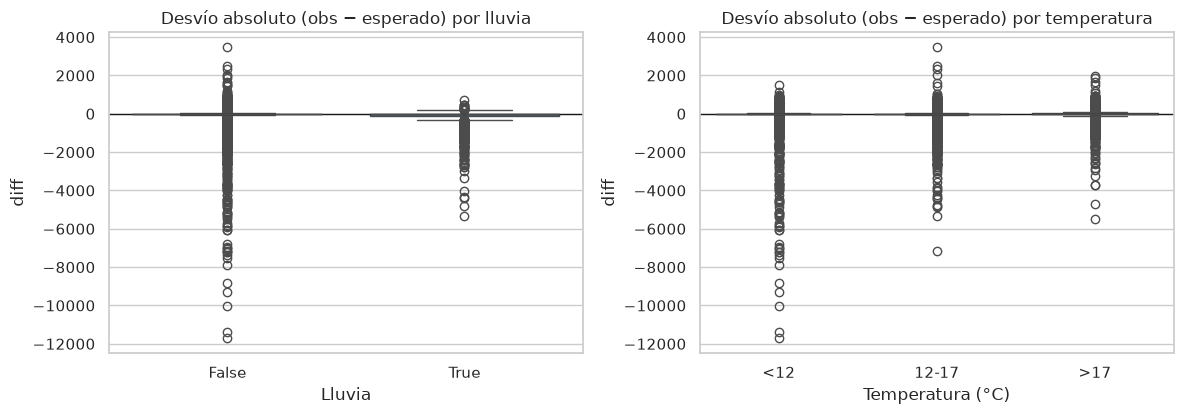

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), sharey=False)
sms = df.sample(min(50000, len(df)), random_state=0)
sns.boxplot(data=sms, x="clima_lluvia", y="diff", ax=axes[0])
axes[0].set_title("Desvío absoluto (obs − esperado) por lluvia")
axes[0].set_xlabel("Lluvia")
axes[0].axhline(0, color="k", lw=1)
sns.boxplot(data=sms, x="clima_temp_cat", y="diff", ax=axes[1], order=["<12", "12-17", ">17"])
axes[1].set_title("Desvío absoluto (obs − esperado) por temperatura")
axes[1].set_xlabel("Temperatura (°C)")
axes[1].axhline(0, color="k", lw=1)
plt.tight_layout(); plt.show()

## 3. Conclusiones

1. **Dataset:** `dataset_final_clima_transmilenio.csv` permite enriquecer los modelos con clima horario; la unión por `(Fecha, Hora)` es completa y sin pérdida de filas.
2. **Lluvia es efecto despreciable:** restringidas a horas sin festivos, las horas con lluvia (32) registran 2–3% menos validaciones que su esperado, dentro del ruido del sistema. Las categorías `moderada`/`fuerte` no existen en el período (solo lluvia ligera), así que no se puede extrapolar a tormentas.
3. **Días festivos:** con las restricción de los campos `Tipo_Dia_ok` y `Es_Festivo`, es decir tomando solo los dias habiles el efecto de la lluvia solo reduce en 2–3% del total de validaciones.
4. **Temperatura -> no causal:** la correlación alta con `temp` es el ciclo horario disfrazado; controlada la franja aporta casi nada.
